In [1]:
%pip -q install pandas numpy matplotlib seaborn statsmodels scipy pymannkendall

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pymannkendall as mk

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

DAILY_CSV = 'Algiers_Weather_Data.csv'
OUT_MONTHLY = 'algiers_monthly_processed_v2.csv'


## A1 : Data audit (schema, coverage, missingness)

In [3]:
df = pd.read_csv(DAILY_CSV)
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)

print('Rows:', len(df))
print('Start:', df['time'].min())
print('End:  ', df['time'].max())
print('Columns:', len(df.columns))
display(df.head())

# Missingness
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
if len(missing) == 0:
    print('No missing values detected.')
else:
    missing_pct = (missing / len(df) * 100).round(3)
    display(pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}))

Rows: 7913
Start: 2002-01-01 00:00:00
End:   2023-08-31 00:00:00
Columns: 19


,time,weathercode (wmo code),temperature_2m_max (°C),temperature_2m_min (°C),temperature_2m_mean (°C),apparent_temperature_max (°C),apparent_temperature_min (°C),apparent_temperature_mean (°C),sunrise (iso8601),sunset (iso8601),precipitation_sum (mm),rain_sum (mm),snowfall_sum (cm),precipitation_hours (h),windspeed_10m_max (km/h),windgusts_10m_max (km/h),winddirection_10m_dominant (°),shortwave_radiation_sum (MJ/m²),et0_fao_evapotranspiration (mm)
0,2002-01-01,3,15.4,10.5,12.2,11.9,7.5,9.2,2002-01-01T09:00,2002-01-01T18:42,0.0,0.0,0.0,0,25.2,41.8,76,6.89,1.27
1,2002-01-02,51,16.2,9.8,12.2,14.1,6.7,9.4,2002-01-02T09:00,2002-01-02T18:42,0.6,0.6,0.0,2,19.1,34.6,128,6.93,1.65
2,2002-01-03,51,17.2,8.4,12.0,15.1,5.2,9.9,2002-01-03T09:00,2002-01-03T18:43,0.1,0.1,0.0,1,13.7,24.1,203,10.43,1.87
3,2002-01-04,61,13.6,7.8,10.2,12.9,6.4,9.1,2002-01-04T09:00,2002-01-04T18:44,6.0,6.0,0.0,15,12.3,24.8,214,8.45,1.02
4,2002-01-05,51,13.8,7.9,10.6,11.7,5.9,8.4,2002-01-05T09:00,2002-01-05T18:45,0.3,0.3,0.0,3,17.1,31.0,83,7.05,1.18


No missing values detected.


## A2 : Cleaning rules (verify units + avoid leakage)
Rules :
- Temperatures: linear interpolation up to 5 days
- Precipitation/rain/snow: fill missing with 0 (explicit assumption)
- ET₀ + radiation + wind: linear interpolation up to 5 days

In [4]:
df_clean = df.copy()

temp_cols = [c for c in df_clean.columns if 'temperature' in c.lower()]
precip_cols = [c for c in df_clean.columns if any(k in c.lower() for k in ['precipitation', 'rain', 'snow'])]
cont_cols = [c for c in df_clean.columns if any(k in c.lower() for k in ['et0', 'radiation', 'wind'])]

for col in temp_cols:
    if col != 'time':
        df_clean[col] = df_clean[col].interpolate(method='linear', limit=5)

for col in precip_cols:
    df_clean[col] = df_clean[col].fillna(0)

for col in cont_cols:
    df_clean[col] = df_clean[col].interpolate(method='linear', limit=5)

# sanity check
print('Remaining missing values:', int(df_clean.isna().sum().sum()))

Remaining missing values: 0


## A2 : Monthly aggregation (critical correction: ET₀ should be SUM)
Daily `et0_fao_evapotranspiration (mm)` is a *daily depth* (mm/day). Monthly ET₀ should be the **sum** of daily values (mm/month), otherwise water-balance and aridity computations have unit mismatch.
We also sum `shortwave_radiation_sum (MJ/m²)` because it is daily energy integrated over the day.

In [5]:
df_clean = df_clean.rename(columns={'time': 'date'})
df_clean = df_clean.set_index('date')

agg = {
    'temperature_2m_mean (°C)': 'mean',
    'temperature_2m_max (°C)': 'mean',
    'temperature_2m_min (°C)': 'mean',
    'precipitation_sum (mm)': 'sum',
    'et0_fao_evapotranspiration (mm)': 'sum',
    'shortwave_radiation_sum (MJ/m²)': 'sum',
    'windspeed_10m_max (km/h)': 'mean',
}

# keep only existing cols
agg = {k: v for k, v in agg.items() if k in df_clean.columns}
print('Aggregation columns:', list(agg.keys()))

monthly = df_clean.resample('MS').agg(agg)

monthly = monthly.rename(columns={
    'temperature_2m_mean (°C)': 'temperature_2m_mean',
    'temperature_2m_max (°C)': 'temperature_2m_max',
    'temperature_2m_min (°C)': 'temperature_2m_min',
    'precipitation_sum (mm)': 'precipitation_sum',
    'et0_fao_evapotranspiration (mm)': 'et0_fao_evapotranspiration',
    'shortwave_radiation_sum (MJ/m²)': 'shortwave_radiation_sum',
    'windspeed_10m_max (km/h)': 'windspeed_10m_max',
})

display(monthly.head())
print('Monthly rows:', len(monthly), '|', monthly.index.min(), '→', monthly.index.max())

Aggregation columns: ['temperature_2m_mean (°C)', 'temperature_2m_max (°C)', 'temperature_2m_min (°C)', 'precipitation_sum (mm)', 'et0_fao_evapotranspiration (mm)', 'shortwave_radiation_sum (MJ/m²)', 'windspeed_10m_max (km/h)']


,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,et0_fao_evapotranspiration,shortwave_radiation_sum,windspeed_10m_max
date,,,,,,,
2002-01-01,9.935484,15.038710,6.025806,46.0,49.58,321.59,14.564516
2002-02-01,11.146429,16.353571,6.753571,12.3,64.85,395.78,16.396429
2002-03-01,13.435484,18.400000,9.148387,39.3,98.36,570.91,21.129032
2002-04-01,14.866667,19.743333,10.046667,28.2,118.59,689.53,19.910000
2002-05-01,18.858065,24.351613,13.329032,23.4,162.17,811.72,22.148387


Monthly rows: 260 | 2002-01-01 00:00:00 → 2023-08-01 00:00:00


## A3 : Feature engineering + drought indices (SPI/SPEI-style)
Notes:
- `temp_anomaly`: here we use a *reference climatology* = first 10 years (2002–2011).
- `SPI_12_z`: z-score of 12‑month rolling precipitation totals (approximation).
- `SPEI_12_z`: z-score of 12‑month rolling water balance (P−ET₀) totals (approximation).

we can upgrade this to distribution fitting (Gamma for SPI, Log-logistic for SPEI).

In [6]:
feat = monthly.copy()

# Baseline climatology for anomaly (first 10 years)
baseline_period = (feat.index.year >= 2002) & (feat.index.year <= 2011)
baseline_temp = float(feat.loc[baseline_period, 'temperature_2m_mean'].mean())
feat['temp_anomaly'] = feat['temperature_2m_mean'] - baseline_temp
print('Baseline temp (2002–2011):', round(baseline_temp, 3))

# Water balance and aridity (units consistent: both mm/month)
if 'precipitation_sum' in feat.columns and 'et0_fao_evapotranspiration' in feat.columns:
    feat['water_balance'] = feat['precipitation_sum'] - feat['et0_fao_evapotranspiration']
    feat['cumulative_water_balance'] = feat['water_balance'].cumsum()
    feat['aridity_index'] = feat['et0_fao_evapotranspiration'] / (feat['precipitation_sum'] + 0.1)

# Rolling stats
feat['temp_rolling_12m'] = feat['temperature_2m_mean'].rolling(12).mean()
feat['precip_rolling_12m'] = feat['precipitation_sum'].rolling(12).sum()

# SPI-like / SPEI-like (z-score standardization)
rollP = feat['precipitation_sum'].rolling(12).sum()
feat['SPI_12_z'] = (rollP - rollP.mean()) / rollP.std(ddof=0)

rollWB = feat['water_balance'].rolling(12).sum() if 'water_balance' in feat.columns else None
if rollWB is not None:
    feat['SPEI_12_z'] = (rollWB - rollWB.mean()) / rollWB.std(ddof=0)

display(feat[['temperature_2m_mean','temp_anomaly','precipitation_sum','et0_fao_evapotranspiration','water_balance','aridity_index','SPI_12_z','SPEI_12_z']].head(15))

Baseline temp (2002–2011): 17.478


,temperature_2m_mean,temp_anomaly,precipitation_sum,et0_fao_evapotranspiration,water_balance,aridity_index,SPI_12_z,SPEI_12_z
date,,,,,,,,
2002-01-01,9.935484,-7.542253,46.0,49.58,-3.58,1.075488,NaN,NaN
2002-02-01,11.146429,-6.331308,12.3,64.85,-52.55,5.229839,NaN,NaN
2002-03-01,13.435484,-4.042253,39.3,98.36,-59.06,2.496447,NaN,NaN
2002-04-01,14.866667,-2.611070,28.2,118.59,-90.39,4.190459,NaN,NaN
2002-05-01,18.858065,1.380328,23.4,162.17,-138.77,6.900851,NaN,NaN
2002-06-01,23.576667,6.098930,1.3,184.89,-183.59,132.064286,NaN,NaN
2002-07-01,24.390323,6.912586,1.9,183.77,-181.87,91.885000,NaN,NaN
2002-08-01,24.451613,6.973876,35.1,156.57,-121.47,4.448011,NaN,NaN
2002-09-01,22.716667,5.238930,21.3,133.24,-111.94,6.226168,NaN,NaN


In [7]:
# Drought event counts based on SPEI-like index
if 'SPEI_12_z' in feat.columns:
    drought_m1 = int((feat['SPEI_12_z'] < -1.0).sum())
    drought_m15 = int((feat['SPEI_12_z'] < -1.5).sum())
    drought_m2 = int((feat['SPEI_12_z'] < -2.0).sum())
    print('Drought months (SPEI_12_z < -1.0):', drought_m1)
    print('Severe drought (SPEI_12_z < -1.5):', drought_m15)
    print('Extreme drought (SPEI_12_z < -2.0):', drought_m2)
    worst = feat['SPEI_12_z'].idxmin()
    print('Worst month:', worst.date(), '| SPEI_12_z:', float(feat.loc[worst,'SPEI_12_z']))

Drought months (SPEI_12_z < -1.0): 45
Severe drought (SPEI_12_z < -1.5): 24
Extreme drought (SPEI_12_z < -2.0): 2
Worst month: 2023-04-01 | SPEI_12_z: -2.339713374430501


## B1 : Stationarity + autocorrelation diagnostics (ADF/KPSS + ACF/PACF)

C:\Users\hp probook\AppData\Local\Temp\ipykernel_15340\1842800412.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kps = kpss(s, regression='ct', nlags='auto')
C:\Users\hp probook\AppData\Local\Temp\ipykernel_15340\1842800412.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kps = kpss(s, regression='ct', nlags='auto')
C:\Users\hp probook\AppData\Local\Temp\ipykernel_15340\1842800412.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kps = kpss(s, regression='ct', nlags='auto')


,name,adf_stat,adf_p,kpss_stat,kpss_p
0,temperature_2m_mean,-2.010482,0.281996,0.017450,0.1
1,precipitation_sum,-3.790603,0.003005,0.045146,0.1
2,et0_fao_evapotranspiration,-2.307681,0.169503,0.020183,0.1


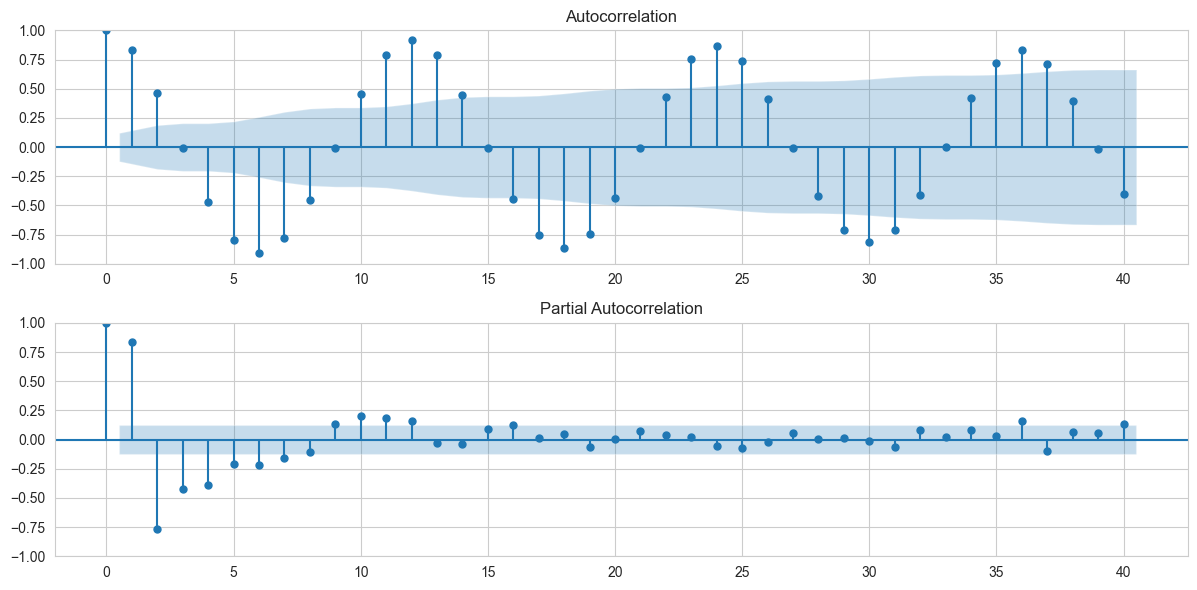

In [8]:
def adf_kpss(series: pd.Series, name: str):
    s = series.dropna().astype(float)
    adf = adfuller(s, autolag='AIC')
    kps = kpss(s, regression='ct', nlags='auto')
    return {
        'name': name,
        'adf_stat': adf[0], 'adf_p': adf[1],
        'kpss_stat': kps[0], 'kpss_p': kps[1]
    }

diag_rows = []
for col in ['temperature_2m_mean','precipitation_sum','et0_fao_evapotranspiration']:
    if col in feat.columns:
        diag_rows.append(adf_kpss(feat[col], col))

display(pd.DataFrame(diag_rows))

# ACF/PACF for temperature
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
plot_acf(feat['temperature_2m_mean'].dropna(), lags=40, ax=axes[0])
plot_pacf(feat['temperature_2m_mean'].dropna(), lags=40, ax=axes[1])
plt.tight_layout()
plt.show()

## B2 : Mann–Kendall + Sen slope (with autocorrelation correction)
We report:
- Original MK (baseline)
- Hamed–Rao modification (accounts for autocorrelation)
- Trend‑free prewhitening modification (alternative correction)
- Sen slope estimate (units per month; converted to per year)

In [9]:
def mk_report(series: pd.Series, name: str):
    x = series.dropna().astype(float).values
    if len(x) < 30:
        return {'variable': name, 'note': 'too few samples'}

    base = mk.original_test(x)
    hr = mk.hamed_rao_modification_test(x)
    tfpw = mk.trend_free_pre_whitening_modification_test(x)
    ss = mk.sens_slope(x)

    slope_per_month = float(ss.slope)
    slope_per_year = slope_per_month * 12.0

    return {
        'variable': name,
        'n': len(x),
        'sen_slope_per_year': slope_per_year,
        'mk_p_original': float(base.p),
        'mk_trend_original': str(base.trend),
        'mk_p_hamed_rao': float(hr.p),
        'mk_trend_hamed_rao': str(hr.trend),
        'mk_p_tfpw': float(tfpw.p),
        'mk_trend_tfpw': str(tfpw.trend),
    }

rows = []
for v in ['temperature_2m_mean','precipitation_sum','et0_fao_evapotranspiration']:
    if v in feat.columns:
        rows.append(mk_report(feat[v], v))

trend_table = pd.DataFrame(rows)
display(trend_table)

,variable,n,sen_slope_per_year,mk_p_original,mk_trend_original,mk_p_hamed_rao,mk_trend_hamed_rao,mk_p_tfpw,mk_trend_tfpw
0,temperature_2m_mean,260,0.079440,0.130898,no trend,0.000968,increasing,0.017458,increasing
1,precipitation_sum,260,-0.197015,0.336085,no trend,0.468622,no trend,0.207586,no trend
2,et0_fao_evapotranspiration,260,0.543477,0.186341,no trend,0.016368,increasing,0.061051,no trend


## Save monthly dataset (v2)

In [10]:
feat_out = feat.copy()
feat_out.index.name = 'date'
feat_out.to_csv(OUT_MONTHLY)
print('Saved:', OUT_MONTHLY)
print('Columns:', feat_out.columns.tolist())

Saved: algiers_monthly_processed_v2.csv
Columns: ['temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min', 'precipitation_sum', 'et0_fao_evapotranspiration', 'shortwave_radiation_sum', 'windspeed_10m_max', 'temp_anomaly', 'water_balance', 'cumulative_water_balance', 'aridity_index', 'temp_rolling_12m', 'precip_rolling_12m', 'SPI_12_z', 'SPEI_12_z']


# Key diff

In [11]:
"""
The diff between algiers_monthly_processed.csv and algiers_monthly_processed_v2.csv:   
ET0 aggregation:
algiers_monthly_processed.csv contains ET0 values ~1–6 (monthly mean),
algiers_monthly_processed_v2.csv contains ET0 values ~40–220 (monthly sum ≈ mean * days). v2 corrected the unit (this is the critical fix).
Water balance / cumulative water balance: recomputed in v2 using summed ET0 → much larger negative/positive magnitudes; cumulative totals change accordingly.
New indices: algiers_monthly_processed_v2.csv includes SPI_12_z and SPEI_12_z (12‑mo standardized indices) and slightly reorganized columns (aridity_index position moved).
Column/order/NA differences: some columns are renamed/shifted; v2 fills/derives additional features (rolling stats, indices) not present / different in v1.
Implication: previous forecasts trained on the v1 ET0 (mean) are scientifically incorrect — re-training on v2 is required.
"""

'\nThe diff between algiers_monthly_processed.csv and algiers_monthly_processed_v2.csv:   \nET0 aggregation:\nalgiers_monthly_processed.csv contains ET0 values ~1–6 (monthly mean),\nalgiers_monthly_processed_v2.csv contains ET0 values ~40–220 (monthly sum ≈ mean * days). v2 corrected the unit (this is the critical fix).\nWater balance / cumulative water balance: recomputed in v2 using summed ET0 → much larger negative/positive magnitudes; cumulative totals change accordingly.\nNew indices: algiers_monthly_processed_v2.csv includes SPI_12_z and SPEI_12_z (12‑mo standardized indices) and slightly reorganized columns (aridity_index position moved).\nColumn/order/NA differences: some columns are renamed/shifted; v2 fills/derives additional features (rolling stats, indices) not present / different in v1.\nImplication: previous forecasts trained on the v1 ET0 (mean) are scientifically incorrect — re-training on v2 is required.\n'